## 3.9 張量移到GPU上
### 3.9.1 管理storage的存放位置
    你可以使用.to(device = 'device name')將張量轉移到設備上面進行運算,但數據**並不會**傳回CPU上面進行計算只會回傳結果
    也可以使用.cuda() .cpu()都可以相互轉移



In [70]:
import torch
import numpy
print(torch.__version__)
print(torch.cuda.is_available())
points = torch.tensor([4.,1.,5.,3.,2.,1.])
#points_gpu =points.cuda()

points = points*2
#points_gpu = points_gpu*2
print(points)
#print(points_gpu)

2.8.0+cpu
False
tensor([ 8.,  2., 10.,  6.,  4.,  2.])


In [71]:
#points.cuda()

In [72]:
#points_gpu.cpu()

In [73]:
points2 = torch.ones(3,4)
#point_np = points2.numpy()
point_np = points2.cpu()

In [74]:
type(point_np)


torch.Tensor

In [75]:
point_np[0][0] = 10.0


In [76]:
points2.storage()

 10.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 12]

### 3.11通用的張量
    除設備上的張量還有其他特定型別的張量表示
- 稀疏張量

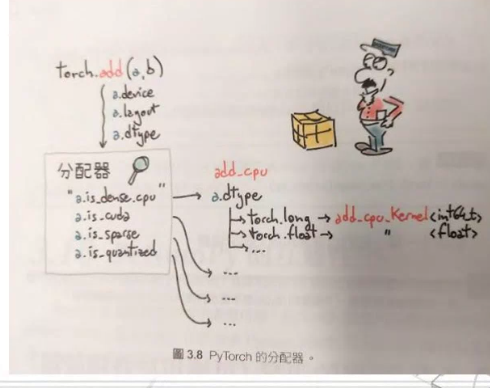
### 3.12 張量序列化(長期儲存)


In [77]:
torch.save(points2, 'points2.t')
   

In [78]:
points3 = torch.load('points2.t')
points3

tensor([[10.,  1.,  1.,  1.],
        [ 1.,  1.,  1.,  1.],
        [ 1.,  1.,  1.,  1.]])

# 04用張量表示現實的資料
    張量是pytorch基礎結構
    本結匯使用圖片及影像進行資料的運算
## 4.1 圖片資料
應用:
-   捲積神經網路

    一張圖片資料可看成一堆純量的集合,排列在特定高寬度的網格中,又稱像素,其內部具有(R,G,B)這三個數值也可以是不同的特徵值.

In [79]:
import numpy as np
import imageio
img_arr = imageio.imread('dog.png')
#img = torch.from_numpy(img_arr)
#img.shape


C:\Users\kevin_kai\AppData\Local\Temp\ipykernel_12532\3496843398.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_arr = imageio.imread('dog.png')


## 調整張量各軸的排列順序
    如果有多張照片可以調整各軸的排列順序進行依些調整
    同樣的,也可以對照片數值進行正規劃

In [80]:
import os 
data_dir = './image-cats/'
filenames = [name for name in os.listdir(data_dir) if os.path.splitext(name)[-1] == '.png']
filenames

['cat1.png', 'cat2.png', 'cat3.png']

In [81]:
batch_size = 3
batch = torch.zeros(batch_size, 3, 256, 256,dtype=torch.uint8)
for i,filename in enumerate(filenames):
    img_arr = imageio.imread(os.path.join(data_dir, filename))
    #img = torch.from_numpy(img_arr)
    img = torch.tensor(img_arr)
    img = img.permute(2,0,1)
    img = img[:3]
    print(f'{i} {filename} {img.shape}')
    batch[i] = img
batch.shape

0 cat1.png torch.Size([3, 256, 256])
1 cat2.png torch.Size([3, 256, 256])
2 cat3.png torch.Size([3, 256, 256])


C:\Users\kevin_kai\AppData\Local\Temp\ipykernel_12532\4190238119.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_arr = imageio.imread(os.path.join(data_dir, filename))


torch.Size([3, 3, 256, 256])

In [82]:
batch = batch.float()
batch = batch/255.0
batch

tensor([[[[0.6118, 0.5961, 0.4863,  ..., 0.5882, 0.5843, 0.6196],
          [0.6824, 0.5255, 0.6471,  ..., 0.4706, 0.5333, 0.5412],
          [0.4980, 0.6118, 0.4196,  ..., 0.5137, 0.5608, 0.6431],
          ...,
          [0.4549, 0.5098, 0.5059,  ..., 0.4980, 0.4627, 0.4392],
          [0.5059, 0.5098, 0.4824,  ..., 0.4510, 0.4745, 0.4471],
          [0.5059, 0.4824, 0.4627,  ..., 0.4431, 0.4745, 0.4706]],

         [[0.5451, 0.5294, 0.4275,  ..., 0.5294, 0.5294, 0.5765],
          [0.6275, 0.4667, 0.5843,  ..., 0.4118, 0.4784, 0.4863],
          [0.4431, 0.5490, 0.3529,  ..., 0.4627, 0.5059, 0.5961],
          ...,
          [0.3882, 0.4314, 0.4353,  ..., 0.4588, 0.4235, 0.4039],
          [0.4353, 0.4353, 0.4157,  ..., 0.4157, 0.4392, 0.4118],
          [0.4353, 0.4078, 0.4000,  ..., 0.4039, 0.4314, 0.4353]],

         [[0.5059, 0.4824, 0.3843,  ..., 0.5137, 0.5176, 0.5686],
          [0.6078, 0.4314, 0.5373,  ..., 0.4000, 0.4667, 0.4745],
          [0.4078, 0.5176, 0.3137,  ..., 0

In [83]:
n_channels = batch.shape[1]
for c in range(n_channels):
    print(f'channel {c} mean: {batch[:,c].mean()} std: {batch[:,c].std()}')
    batch[:,c] = (batch[:,c] - batch[:,c].mean())/batch[:,c].std()
    

channel 0 mean: 0.5799327492713928 std: 0.22118069231510162
channel 1 mean: 0.4493196904659271 std: 0.20676465332508087
channel 2 mean: 0.35544052720069885 std: 0.1930793672800064


### 4.1.4 將資料內的向素質做轉換
    圖片資料需要將他正則化縮放至0-1之間進行製作